# FIFA World Cup 1930-2026: Comprehensive Analysis

This notebook analyzes World Cup data spanning nearly a century of football history.

**Datasets:**
- `WC_1930-2014.csv` — 852 historical matches (1930-2014)
- `World_cup_2018_*.csv` — 2018 Russia: 64 matches, 169 goals, 32 team rankings
- `WC_2022.csv` — 64 matches with 88 detailed statistics columns
- `*.csv` (2026 files) — Complete 2026 tournament data (matches, teams, players, events, lineups)

## 1. Setup & Data Loading

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 30)

In [19]:
# Load all datasets
print("Loading datasets...")

# Historical matches 1930-2014
hist = pd.read_csv('WC_1930-2014.csv')
hist = hist.dropna(subset=['Year'])
hist['Year'] = hist['Year'].astype(int)
print(f"✓ WC_1930-2014: {len(hist)} matches")

# 2018 World Cup data
# 2018 data files are now in current directory
matches_2018 = pd.read_csv('World_cup_2018_matches.csv')
goals_2018 = pd.read_csv('World_cup_2018_goals.csv')
countries_2018 = pd.read_csv('World_cup_2018_country.csv')
print(f"✓ WC_2018: {len(matches_2018)} matches, {len(goals_2018)} goals, {len(countries_2018)} teams")

# 2022 detailed stats
matches_2022 = pd.read_csv('WC_2022.csv')
print(f"✓ WC_2022: {len(matches_2022)} matches × {len(matches_2022.columns)} columns")

# 2026 dataset
# 2026 data files are now in current directory
matches_2026 = pd.read_csv('matches.csv')
teams_2026 = pd.read_csv('teams.csv')
venues_2026 = pd.read_csv('venues.csv')
players_2026 = pd.read_csv('squads_and_players.csv')
events_2026 = pd.read_csv('match_events.csv')
lineups_2026 = pd.read_csv('match_lineups.csv')
player_stats_2026 = pd.read_csv('player_stats.csv')
team_stats_2026 = pd.read_csv('match_team_stats.csv')
print(f"✓ WC_2026: {len(matches_2026)} matches, {len(teams_2026)} teams, {len(players_2026)} players")

print("\nAll datasets loaded successfully!")

Loading datasets...
✓ WC_1930-2014: 852 matches
✓ WC_2018: 64 matches, 169 goals, 32 teams
✓ WC_2022: 64 matches × 88 columns
✓ WC_2026: 104 matches, 48 teams, 1248 players

All datasets loaded successfully!


## 2. Historical Analysis (1930-2014)

In [20]:
# Clean team names
import re

def clean_team(name):
    if pd.isna(name):
        return None
    s = str(name).strip()
    s = re.sub(r'^rn"?>', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    aliases = {'Columbia': 'Colombia', 'Costarica': 'Costa Rica', 'Porugal': 'Portugal'}
    return aliases.get(s, s)

hist['Home Team Name'] = hist['Home Team Name'].map(clean_team)
hist['Away Team Name'] = hist['Away Team Name'].map(clean_team)
hist['total_goals'] = hist['Home Team Goals'] + hist['Away Team Goals']

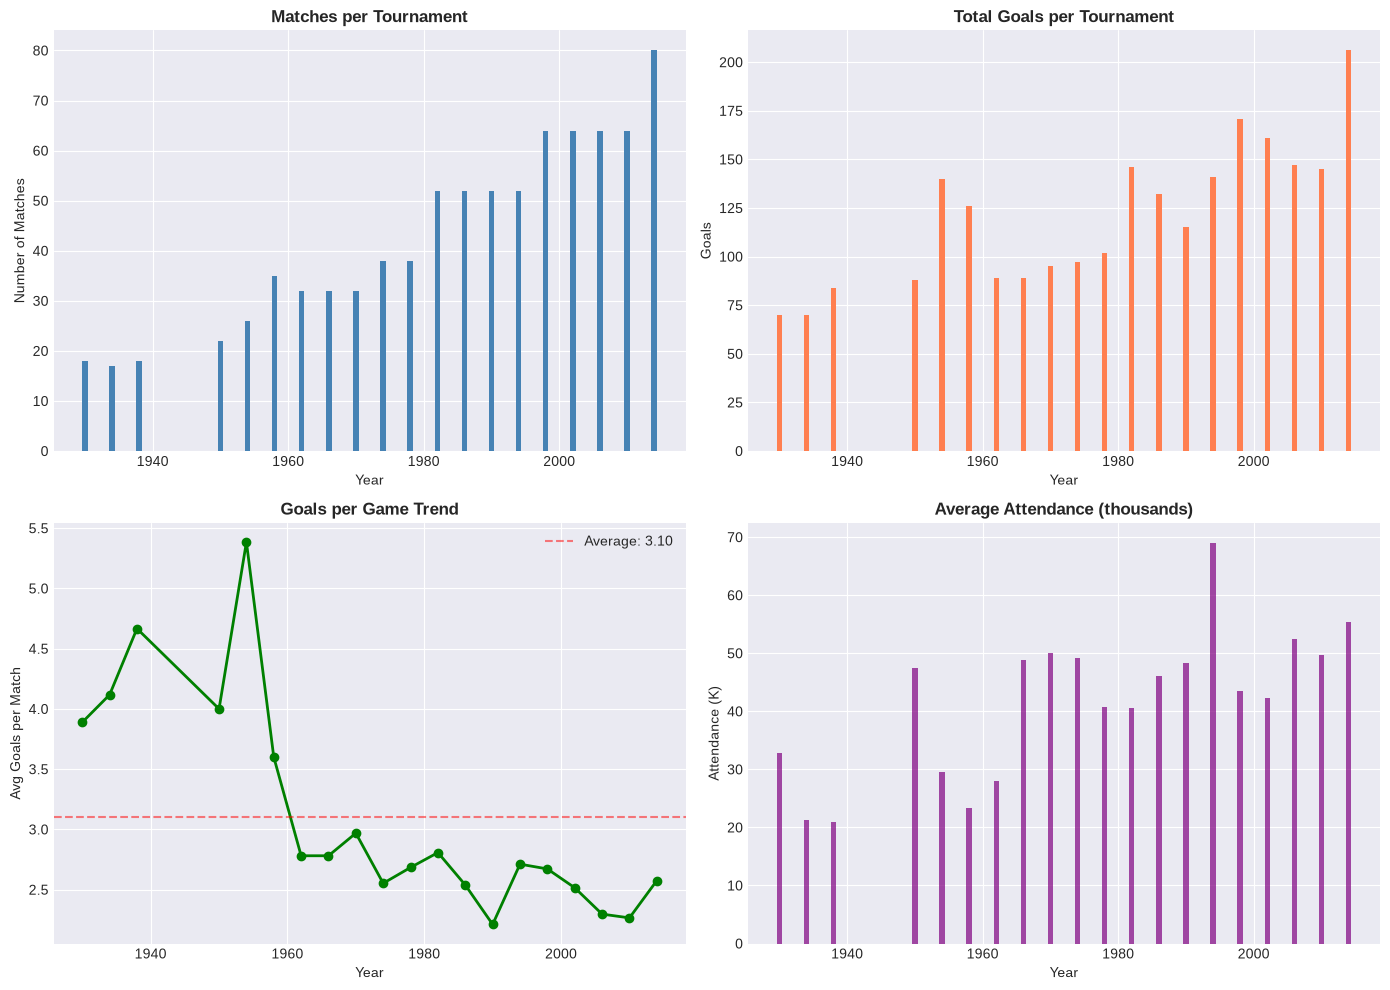


Tournament Growth Summary:
• First tournament (1930): 18 matches
• Latest in dataset (2014): 80 matches
• Highest scoring: 1954 (5.38 goals/game)
• Lowest scoring: 1990 (2.21 goals/game)


In [21]:
# Tournament growth over time
yearly_stats = hist.groupby('Year').agg(
    matches=('MatchID', 'count'),
    goals=('total_goals', 'sum'),
    avg_goals=('total_goals', 'mean'),
    avg_attendance=('Attendance', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Matches per tournament
axes[0,0].bar(yearly_stats['Year'], yearly_stats['matches'], color='steelblue')
axes[0,0].set_title('Matches per Tournament', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Matches')

# Total goals per tournament
axes[0,1].bar(yearly_stats['Year'], yearly_stats['goals'], color='coral')
axes[0,1].set_title('Total Goals per Tournament', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Goals')

# Goals per game trend
axes[1,0].plot(yearly_stats['Year'], yearly_stats['avg_goals'], 'o-', color='green', linewidth=2)
axes[1,0].axhline(y=yearly_stats['avg_goals'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Average: {yearly_stats["avg_goals"].mean():.2f}')
axes[1,0].set_title('Goals per Game Trend', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Avg Goals per Match')
axes[1,0].legend()

# Average attendance
axes[1,1].bar(yearly_stats['Year'], yearly_stats['avg_attendance']/1000, color='purple', alpha=0.7)
axes[1,1].set_title('Average Attendance (thousands)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Attendance (K)')

plt.tight_layout()
plt.show()

print(f"\nTournament Growth Summary:")
print(f"• First tournament (1930): {yearly_stats.iloc[0]['matches']:.0f} matches")
print(f"• Latest in dataset (2014): {yearly_stats.iloc[-1]['matches']:.0f} matches")
print(f"• Highest scoring: {yearly_stats.loc[yearly_stats['avg_goals'].idxmax(), 'Year']:.0f} ({yearly_stats['avg_goals'].max():.2f} goals/game)")
print(f"• Lowest scoring: {yearly_stats.loc[yearly_stats['avg_goals'].idxmin(), 'Year']:.0f} ({yearly_stats['avg_goals'].min():.2f} goals/game)")

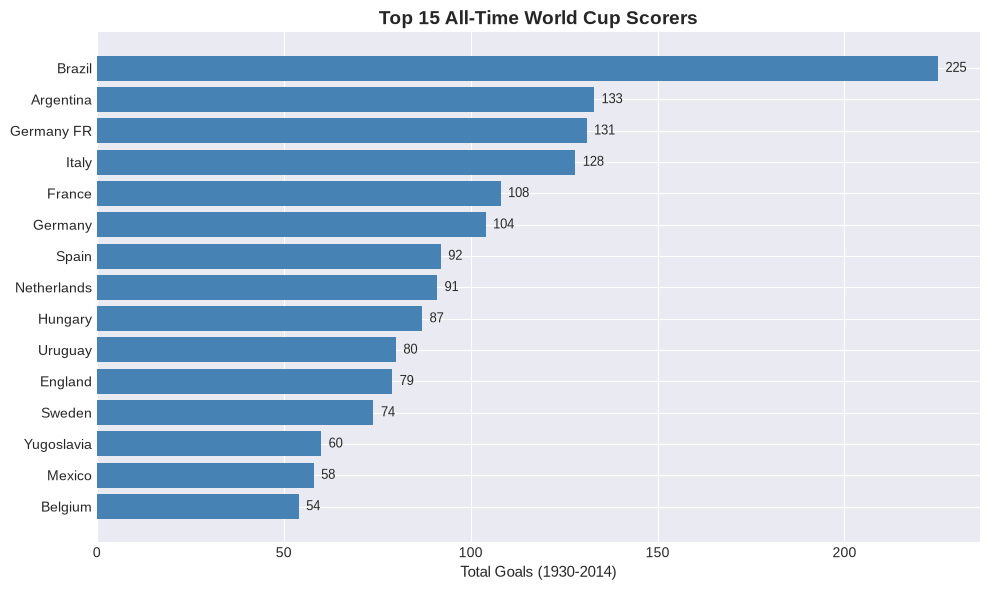

In [22]:
# All-time top scoring nations
goals_by_team = {}
for _, r in hist.iterrows():
    home = r['Home Team Name']
    away = r['Away Team Name']
    if home:
        goals_by_team[home] = goals_by_team.get(home, 0) + r['Home Team Goals']
    if away:
        goals_by_team[away] = goals_by_team.get(away, 0) + r['Away Team Goals']

top_scorers = pd.DataFrame([
    {'Team': k, 'Goals': v} 
    for k, v in sorted(goals_by_team.items(), key=lambda x: -x[1])[:15]
])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_scorers['Team'][::-1], top_scorers['Goals'][::-1], color='steelblue')
ax.set_xlabel('Total Goals (1930-2014)', fontsize=11)
ax.set_title('Top 15 All-Time World Cup Scorers', fontsize=14, fontweight='bold')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

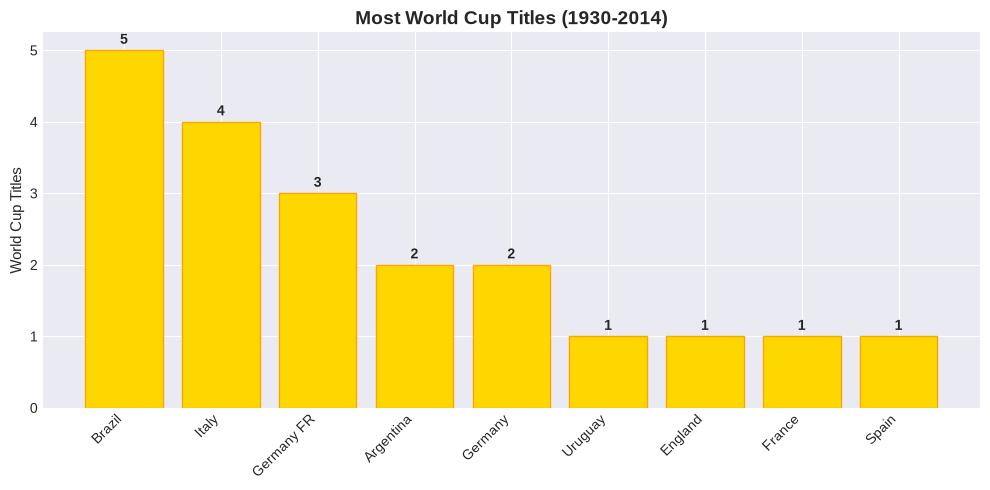


Finals Summary:
1930: Uruguay 4-2 Argentina → Uruguay
1934: Italy 2-1 Czechoslovakia → Italy (Italy win after extra time)
1938: Italy 4-2 Hungary → Italy
1954: Germany FR 3-2 Hungary → Germany FR
1958: Brazil 5-2 Sweden → Brazil
1962: Brazil 3-1 Czechoslovakia → Brazil
1966: England 4-2 Germany FR → England (England win after extra time)
1970: Brazil 4-1 Italy → Brazil
1974: Netherlands 1-2 Germany FR → Germany FR
1978: Argentina 3-1 Netherlands → Argentina (Argentina win after extra time)
1982: Italy 3-1 Germany FR → Italy
1986: Argentina 3-2 Germany FR → Argentina
1990: Germany FR 1-0 Argentina → Germany FR
1994: Brazil 0-0 Italy → Brazil (Brazil win on penalties (3 - 2))
1998: Brazil 0-3 France → France
2002: Germany 0-2 Brazil → Brazil
2006: Italy 1-1 France → Italy (Italy win on penalties (5 - 3))
2010: Netherlands 0-1 Spain → Spain (Spain win after extra time)
2014: Germany 1-0 Argentina → Germany (Germany win after extra time)
2014: Germany 1-0 Argentina → Germany (Germany win 

In [23]:
# Finals history
finals = hist[hist['Stage'] == 'Final'].sort_values('Year')

def get_champion(row):
    wc = str(row['Win conditions']).strip() if pd.notna(row['Win conditions']) else ''
    if wc:
        return wc.split()[0]
    if row['Home Team Goals'] > row['Away Team Goals']:
        return row['Home Team Name']
    return row['Away Team Name']

finals['Champion'] = finals.apply(get_champion, axis=1)
champion_counts = finals['Champion'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(champion_counts.index, champion_counts.values, color='gold', edgecolor='orange')
ax.set_ylabel('World Cup Titles', fontsize=11)
ax.set_title('Most World Cup Titles (1930-2014)', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05, f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFinals Summary:")
for _, r in finals.iterrows():
    score = f"{int(r['Home Team Goals'])}-{int(r['Away Team Goals'])}"
    wc = f" ({r['Win conditions'].strip()})" if pd.notna(r['Win conditions']) and str(r['Win conditions']).strip() else ''
    print(f"{r['Year']}: {r['Home Team Name']} {score} {r['Away Team Name']} → {r['Champion']}{wc}")

## 3. 2018 World Cup Analysis

In [24]:
# 2018 Tournament overview
print("2018 World Cup - Russia")
print(f"="*50)
print(f"Matches: {len(matches_2018)}")
print(f"Goals: {len(goals_2018)}")
print(f"Teams: {len(countries_2018)}")

# Display country rankings
print("\nTop 10 Teams by World Ranking:")
top_ranked = countries_2018.nsmallest(10, 'World_ranking')[['Country', 'World_ranking', 'Group', 'Tournament_ranking']]
display(top_ranked)

2018 World Cup - Russia
Matches: 64
Goals: 169
Teams: 32

Top 10 Teams by World Ranking:


,Country,World_ranking,Group,Tournament_ranking
0,Germany,1,F,1
1,Brazil,2,E,2
2,Belgium,3,G,3
3,Portugal,4,B,4
4,Argentina,5,D,5
5,Switzerland,6,E,6
6,France,7,C,7
7,Poland,8,H,8
8,Spain,10,B,9
9,Peru,11,C,10


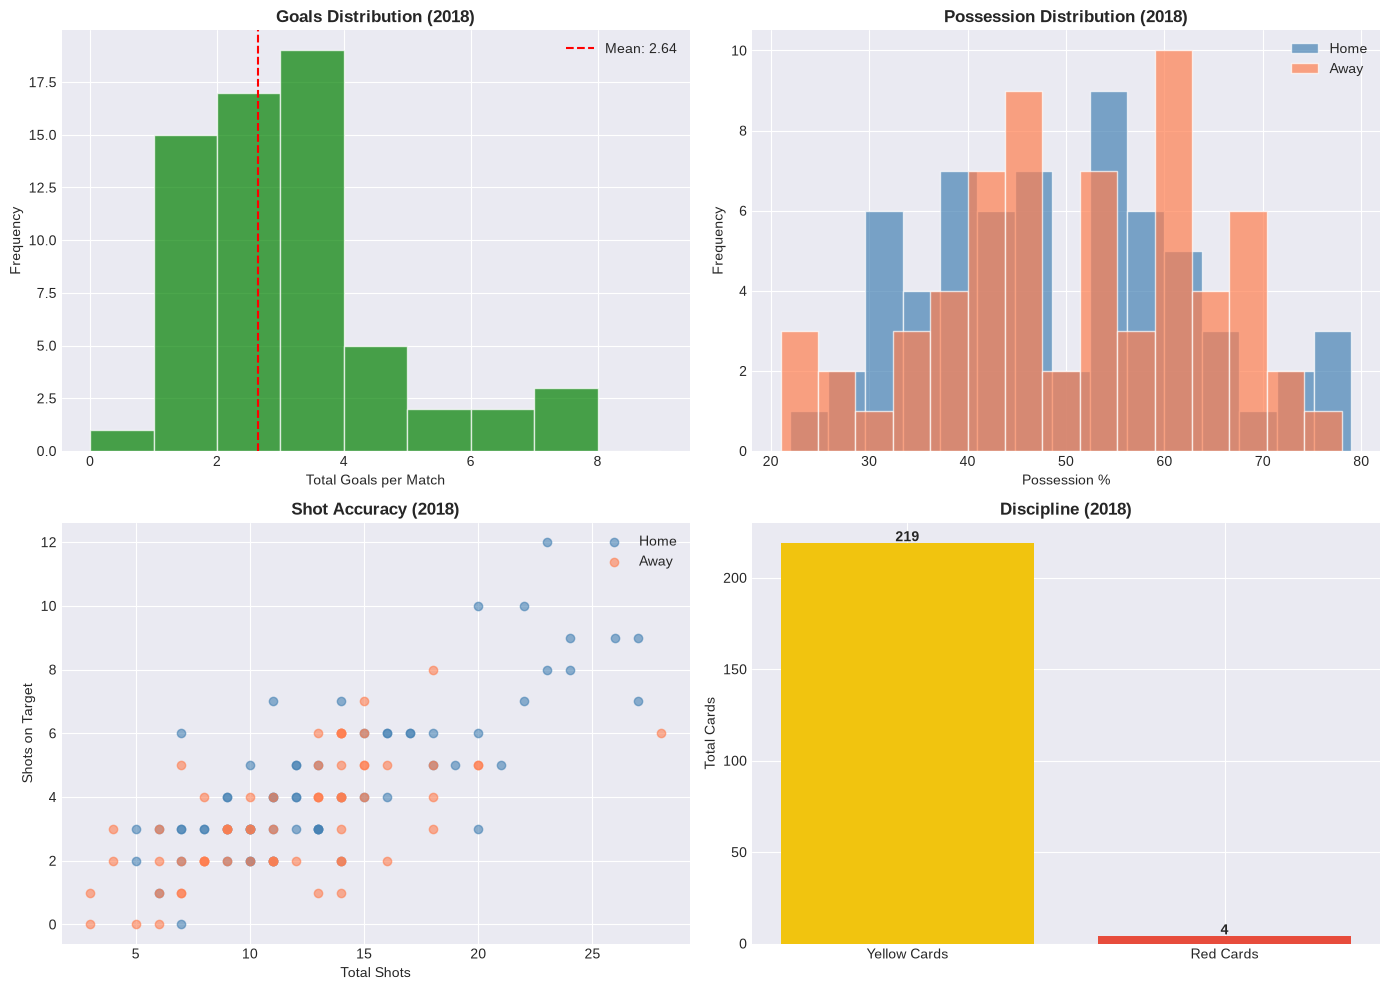

In [25]:
# 2018 Match statistics
matches_2018['total_goals'] = matches_2018['Home_goals'] + matches_2018['Away_goals']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Goals distribution
axes[0,0].hist(matches_2018['total_goals'], bins=range(0, 10), color='green', edgecolor='white', alpha=0.7)
axes[0,0].set_xlabel('Total Goals per Match')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Goals Distribution (2018)', fontsize=12, fontweight='bold')
axes[0,0].axvline(matches_2018['total_goals'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {matches_2018["total_goals"].mean():.2f}')
axes[0,0].legend()

# Possession distribution
axes[0,1].hist(matches_2018['Home_possession'], bins=15, color='steelblue', edgecolor='white', alpha=0.7, label='Home')
axes[0,1].hist(matches_2018['Away_possession'], bins=15, color='coral', edgecolor='white', alpha=0.7, label='Away')
axes[0,1].set_xlabel('Possession %')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Possession Distribution (2018)', fontsize=12, fontweight='bold')
axes[0,1].legend()

# Shots vs Shots on Target
axes[1,0].scatter(matches_2018['Home_shots'], matches_2018['Home_shots_on_target'], 
                 alpha=0.6, color='steelblue', label='Home')
axes[1,0].scatter(matches_2018['Away_shots'], matches_2018['Away_shots_on_target'],
                 alpha=0.6, color='coral', label='Away')
axes[1,0].set_xlabel('Total Shots')
axes[1,0].set_ylabel('Shots on Target')
axes[1,0].set_title('Shot Accuracy (2018)', fontsize=12, fontweight='bold')
axes[1,0].legend()

# Cards distribution
cards_data = [matches_2018['Home_yellow'].sum() + matches_2018['Away_yellow'].sum(),
              matches_2018['Home_red'].sum() + matches_2018['Away_red'].sum()]
axes[1,1].bar(['Yellow Cards', 'Red Cards'], cards_data, color=['#f1c40f', '#e74c3c'])
axes[1,1].set_ylabel('Total Cards')
axes[1,1].set_title('Discipline (2018)', fontsize=12, fontweight='bold')

for i, v in enumerate(cards_data):
    axes[1,1].text(i, v + 1, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# 2018 Team performance aggregation
def aggregate_2018_team_stats(df):
    teams = {}
    for _, r in df.iterrows():
        for team_col, is_home in [('Home', True), ('Away', False)]:
            team = r[team_col]
            if team not in teams:
                teams[team] = {'matches': 0, 'goals_for': 0, 'goals_against': 0, 
                             'shots': [], 'shots_on_target': [], 'possession': [], 'fouls': [], 'corners': []}
            
            teams[team]['matches'] += 1
            teams[team]['goals_for'] += r[f'{team_col}_goals']
            teams[team]['goals_against'] += r['Away_goals' if is_home else 'Home_goals']
            teams[team]['shots'].append(r[f'{team_col}_shots'])
            teams[team]['shots_on_target'].append(r[f'{team_col}_shots_on_target'])
            teams[team]['possession'].append(r[f'{team_col}_possession'])
            teams[team]['fouls'].append(r[f'{team_col}_fouls'])
            teams[team]['corners'].append(r[f'{team_col}_corners'])
    
    result = []
    for team, stats in teams.items():
        result.append({
            'Team': team,
            'Matches': stats['matches'],
            'Goals For': stats['goals_for'],
            'Goals Against': stats['goals_against'],
            'Goal Diff': stats['goals_for'] - stats['goals_against'],
            'Avg Possession %': np.mean(stats['possession']),
            'Avg Shots': np.mean(stats['shots']),
            'Avg Shots on Target': np.mean(stats['shots_on_target']),
            'Avg Fouls': np.mean(stats['fouls']),
            'Avg Corners': np.mean(stats['corners'])
        })
    return pd.DataFrame(result).sort_values('Goal Diff', ascending=False)

team_perf_2018 = aggregate_2018_team_stats(matches_2018)
print("Top 10 Teams by Goal Difference (2018):")
display(team_perf_2018.head(10))

Top 10 Teams by Goal Difference (2018):


,Team,Matches,Goals For,Goals Against,Goal Diff,Avg Possession %,Avg Shots,Avg Shots on Target,Avg Fouls,Avg Corners
24,Belgium,7,16,6,10,52.857143,15.142857,5.714286,14.142857,5.571429
14,Croatia,7,16,7,9,52.571429,15.142857,4.428571,16.000000,5.142857
20,Brazil,5,8,3,5,58.600000,20.800000,8.000000,9.800000,8.200000
0,Russia,5,11,7,4,37.000000,9.600000,3.400000,19.000000,5.200000
8,France,7,12,8,4,52.714286,12.571429,3.857143,13.142857,3.571429
27,England,7,12,8,4,54.285714,13.428571,4.142857,10.000000,5.571429
3,Uruguay,5,7,3,4,47.000000,12.000000,4.200000,12.600000,3.600000
28,Colombia,4,6,3,3,50.000000,9.750000,3.250000,15.750000,3.250000
22,Sweden,5,6,4,2,37.400000,11.000000,4.000000,13.000000,3.200000
7,Spain,4,7,6,1,74.750000,18.250000,6.250000,8.500000,6.000000


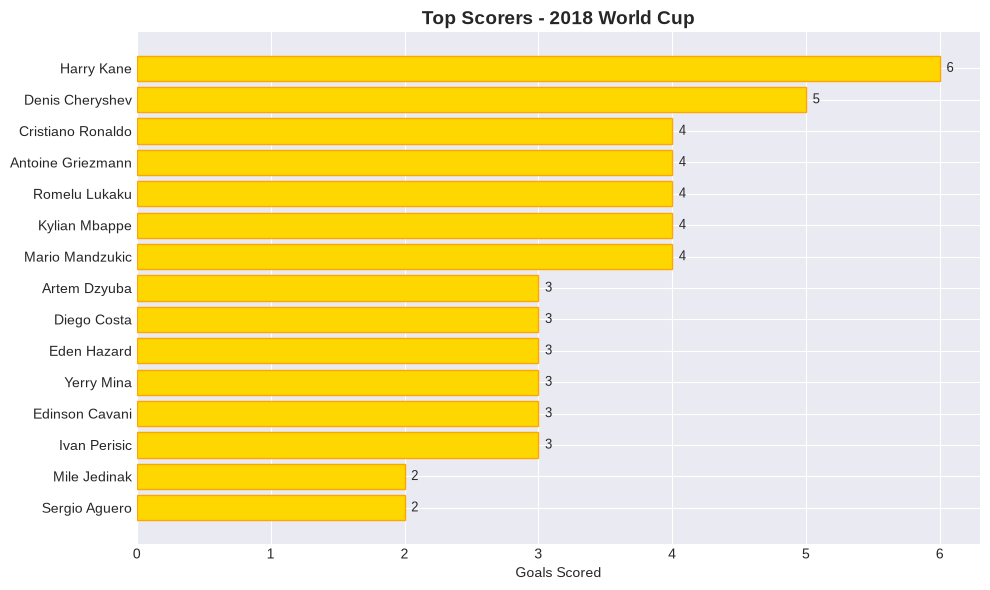

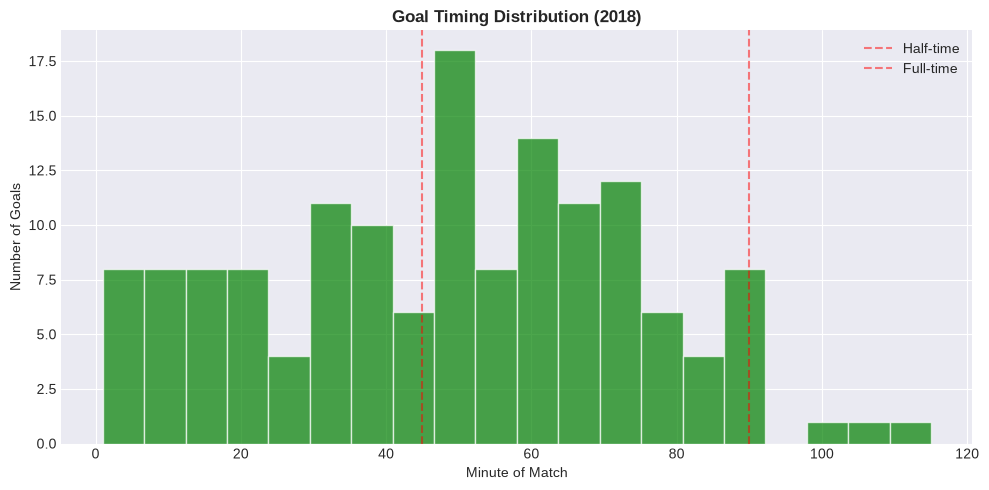

In [27]:
# 2018 Top scorers
top_scorers_2018 = goals_2018['Player_scored'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_scorers_2018.index[::-1], top_scorers_2018.values[::-1], color='gold', edgecolor='orange')
ax.set_xlabel('Goals Scored')
ax.set_title('Top Scorers - 2018 World Cup', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Goal timing analysis
goals_2018['Time_numeric'] = pd.to_numeric(goals_2018['Time'].astype(str).str.replace('+.*', ''), errors='coerce')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(goals_2018['Time_numeric'].dropna(), bins=20, color='green', edgecolor='white', alpha=0.7)
ax.axvline(45, color='red', linestyle='--', alpha=0.5, label='Half-time')
ax.axvline(90, color='red', linestyle='--', alpha=0.5, label='Full-time')
ax.set_xlabel('Minute of Match')
ax.set_ylabel('Number of Goals')
ax.set_title('Goal Timing Distribution (2018)', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

2018 World Cup - Tournament Progression
Last16: 16 teams
QFinals: 8 teams
SFinals: 4 teams
Finals: 2 teams
Winner: 1 teams

🏆 Champion: France


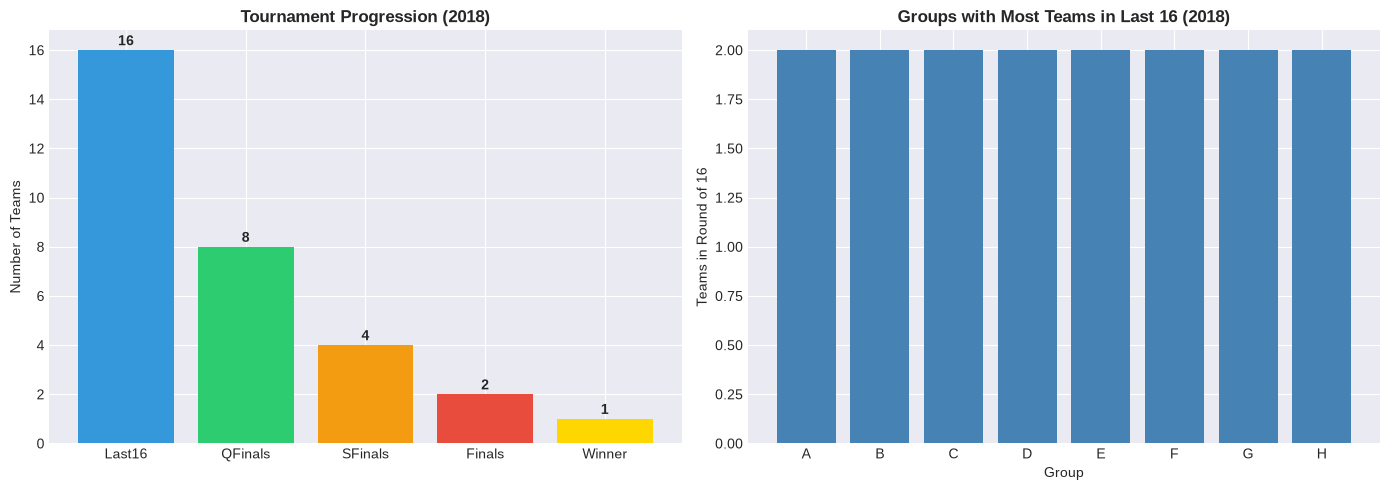

In [28]:
# 2018 Tournament progression
print("2018 World Cup - Tournament Progression")
print("="*50)

# Count teams reaching each stage
stages = ['Last16', 'QFinals', 'SFinals', 'Finals', 'Winner']
stage_counts = []
for stage in stages:
    count = (countries_2018[stage] == 'Y').sum()
    stage_counts.append(count)
    print(f"{stage}: {count} teams")

# Winner
winner = countries_2018[countries_2018['Winner'] == 'Y']['Country'].values[0]
print(f"\n🏆 Champion: {winner}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stage progression funnel
axes[0].bar(stages, stage_counts, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', 'gold'])
axes[0].set_ylabel('Number of Teams')
axes[0].set_title('Tournament Progression (2018)', fontsize=12, fontweight='bold')

for i, v in enumerate(stage_counts):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Group performance
group_perf = countries_2018.groupby('Group').agg(
    avg_rank=('World_ranking', 'mean'),
    teams_in_last16=('Last16', lambda x: (x == 'Y').sum())
).reset_index()

axes[1].bar(group_perf['Group'], group_perf['teams_in_last16'], color='steelblue')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Teams in Round of 16')
axes[1].set_title('Groups with Most Teams in Last 16 (2018)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. 2022 World Cup Deep Dive

In [29]:
# 2022 Match statistics overview
print(f"2022 World Cup: {len(matches_2022)} matches")
print(f"Statistics columns: {len(matches_2022.columns)}")

# Key stats columns
key_stats = ['possession team1', 'possession team2', 'total attempts team1', 'total attempts team2',
             'on target attempts team1', 'on target attempts team2', 'passes completed team1', 'passes completed team2']

print("\nSample of key statistics:")
display(matches_2022[['team1', 'team2', 'category'] + key_stats].head(10))

2022 World Cup: 64 matches
Statistics columns: 88

Sample of key statistics:


,team1,team2,category,possession team1,possession team2,total attempts team1,total attempts team2,on target attempts team1,on target attempts team2,passes completed team1,passes completed team2
0,QATAR,ECUADOR,Group A,42%,50%,5,6,0,3,381,409
1,ENGLAND,IRAN,Group B,72%,19%,13,8,7,3,730,154
2,SENEGAL,NETHERLANDS,Group A,44%,45%,14,9,3,3,313,374
3,UNITED STATES,WALES,Group B,51%,39%,6,7,1,3,509,321
4,ARGENTINA,SAUDI ARABIA,Group C,64%,24%,14,3,6,2,529,190
5,DENMARK,TUNISIA,Group D,55%,33%,11,11,4,1,523,302
6,MEXICO,POLAND,Group C,54%,31%,13,8,4,1,422,241
7,FRANCE,AUSTRALIA,Group D,56%,35%,22,4,7,1,672,399
8,MOROCCO,CROATIA,Group F,32%,57%,8,6,2,2,290,592
9,GERMANY,JAPAN,Group E,65%,22%,25,10,9,3,743,207


In [30]:
# 2022 Team performance aggregation
def aggregate_team_stats(df):
    teams = {}
    for _, r in df.iterrows():
        for team_col, prefix in [('team1', ''), ('team2', '2')]:
            team = r[team_col]
            if team not in teams:
                teams[team] = {'matches': 0, 'goals_for': 0, 'goals_against': 0, 
                             'possession': [], 'shots': [], 'shots_on_target': [], 'passes': []}
            
            teams[team]['matches'] += 1
            teams[team]['goals_for'] += r[f'number of goals team{1 if prefix=="" else 2}']
            teams[team]['goals_against'] += r[f'number of goals team{2 if prefix=="" else 1}']
            teams[team]['possession'].append(r[f'possession {team_col}'])
            teams[team]['shots'].append(r[f'total attempts {team_col}'])
            teams[team]['shots_on_target'].append(r[f'on target attempts {team_col}'])
            teams[team]['passes'].append(r[f'passes completed {team_col}'])
    
    result = []
    for team, stats in teams.items():
        result.append({
            'Team': team.title(),
            'Matches': stats['matches'],
            'Goals For': stats['goals_for'],
            'Goals Against': stats['goals_against'],
            'Goal Diff': stats['goals_for'] - stats['goals_against'],
            'Avg Possession %': np.mean(stats['possession']),
            'Avg Shots': np.mean(stats['shots']),
            'Avg Shots on Target': np.mean(stats['shots_on_target']),
            'Avg Passes': np.mean(stats['passes'])
        })
    return pd.DataFrame(result).sort_values('Goal Diff', ascending=False)

team_perf_2022 = aggregate_team_stats(matches_2022)
print("Top 10 Teams by Goal Difference (2022):")
display(team_perf_2022.head(10))

TypeError: the resolved dtypes are not compatible with add.reduce. Resolved (dtype('<U3'), dtype('<U3'), dtype('<U6'))

In [ ]:
# 2022 Possession vs Goals visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Possession vs Goals
axes[0].scatter(team_perf_2022['Avg Possession %'], team_perf_2022['Goals For'], 
               s=100, alpha=0.6, c='steelblue')
for _, row in team_perf_2022.head(5).iterrows():
    axes[0].annotate(row['Team'], (row['Avg Possession %'], row['Goals For']),
                    fontsize=8, ha='center', va='bottom')
axes[0].set_xlabel('Average Possession %')
axes[0].set_ylabel('Total Goals')
axes[0].set_title('Possession vs Goals (2022)', fontsize=12, fontweight='bold')

# Shots efficiency
axes[1].scatter(team_perf_2022['Avg Shots'], team_perf_2022['Avg Shots on Target'],
               s=100, alpha=0.6, c='coral')
for _, row in team_perf_2022.head(5).iterrows():
    axes[1].annotate(row['Team'], (row['Avg Shots'], row['Avg Shots on Target']),
                    fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel('Average Shots per Match')
axes[1].set_ylabel('Average Shots on Target')
axes[1].set_title('Shot Accuracy (2022)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 2022 Match stage analysis
stage_stats = matches_2022.groupby('category').agg(
    matches=('team1', 'count'),
    avg_goals=('number of goals team1', lambda x: x.sum() + matches_2022.loc[x.index, 'number of goals team2'].sum()),
    avg_possession_diff=('possession team1', lambda x: abs(x - matches_2022.loc[x.index, 'possession team2']).mean())
).reset_index()

stage_stats['avg_goals_per_match'] = stage_stats['avg_goals'] / stage_stats['matches']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stage_stats['category'], stage_stats['avg_goals_per_match'], 
              color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
ax.set_ylabel('Average Goals per Match')
ax.set_title('Goals per Match by Stage (2022)', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05, f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. 2026 World Cup Analysis

In [ ]:
# 2026 Tournament overview
print("2026 World Cup - First 48-Team Tournament")
print(f"="*50)
print(f"Teams: {len(teams_2026)}")
print(f"Matches: {len(matches_2026)}")
print(f"Venues: {len(venues_2026)}")
print(f"Players: {len(players_2026)}")
print(f"Match Events: {len(events_2026)}")

# Group distribution
groups_2026 = teams_2026['group_letter'].value_counts().sort_index()
print(f"\nGroups: {len(groups_2026)} (each with {groups_2026.iloc[0]} teams)")

# Confederation representation
conf_counts = teams_2026['confederation'].value_counts()
print("\nConfederation Representation:")
for conf, count in conf_counts.items():
    print(f"  {conf}: {count} teams")

In [ ]:
# 2026 Team rankings and squad values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FIFA Rankings distribution
axes[0].hist(teams_2026['fifa_ranking_pre_tournament'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('FIFA Ranking')
axes[0].set_ylabel('Number of Teams')
axes[0].set_title('Distribution of FIFA Rankings (2026)', fontsize=12, fontweight='bold')

# Top teams by ELO rating
top_elo = teams_2026.nlargest(15, 'elo_rating')[['team_name', 'elo_rating', 'confederation']]
colors = {'UEFA': '#3498db', 'CONMEBOL': '#2ecc71', 'CONCACAF': '#e74c3c', 
          'AFC': '#f39c12', 'CAF': '#9b59b6', 'OFC': '#1abc9c'}
bar_colors = [colors.get(c, 'gray') for c in top_elo['confederation']]

axes[1].barh(top_elo['team_name'][::-1], top_elo['elo_rating'][::-1], color=bar_colors[::-1])
axes[1].set_xlabel('ELO Rating')
axes[1].set_title('Top 15 Teams by ELO Rating (2026)', fontsize=12, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items() if k in teams_2026['confederation'].unique()]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 2026 Venue analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stadium capacities
venues_sorted = venues_2026.sort_values('capacity', ascending=True)
axes[0].barh(venues_sorted['stadium_name'].str.split('(').str[0].str.strip(), 
            venues_sorted['capacity']/1000, color='steelblue')
axes[0].set_xlabel('Capacity (thousands)')
axes[0].set_title('Stadium Capacities (2026)', fontsize=12, fontweight='bold')

# Matches per country
matches_per_country = venues_2026.merge(
    matches_2026.groupby('venue_id').size().reset_index(name='matches'),
    left_on='venue_id', right_on='venue_id'
).groupby('country')['matches'].sum()

axes[1].pie(matches_per_country, labels=matches_per_country.index, autopct='%1.1f%%',
           colors=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('Matches by Host Country (2026)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 2026 Player analysis
print(f"Total Players: {len(players_2026)}")
print(f"Players per Team: {len(players_2026) / len(teams_2026):.0f}")

# Position distribution
pos_counts = players_2026['position'].value_counts()
print("\nPosition Distribution:")
for pos, count in pos_counts.items():
    print(f"  {pos}: {count} ({count/len(players_2026)*100:.1f}%)")

# Age distribution
players_2026['birth_year'] = pd.to_datetime(players_2026['date_of_birth']).dt.year
players_2026['age'] = 2026 - players_2026['birth_year']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(players_2026['age'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(players_2026['age'].mean(), color='red', linestyle='--', 
               label=f'Mean: {players_2026["age"].mean():.1f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Players')
axes[0].set_title('Player Age Distribution (2026)', fontsize=12, fontweight='bold')
axes[0].legend()

# Market value by position
pos_value = players_2026.groupby('position')['market_value_eur'].mean().sort_values(ascending=True) / 1e6
axes[1].barh(pos_value.index, pos_value.values, color='gold')
axes[1].set_xlabel('Average Market Value (€M)')
axes[1].set_title('Average Market Value by Position (2026)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 2026 Match events analysis
print(f"Total Events: {len(events_2026)}")

# Event type distribution
event_types = events_2026['event_type'].value_counts()
print("\nEvent Types:")
for event, count in event_types.items():
    print(f"  {event}: {count}")

# Goals timeline
goals = events_2026[events_2026['event_type'] == 'Goal']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goals by minute
axes[0].hist(goals['minute'], bins=20, color='green', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Minute of Match')
axes[0].set_ylabel('Number of Goals')
axes[0].set_title('Goal Distribution by Minute (2026)', fontsize=12, fontweight='bold')
axes[0].axvline(45, color='red', linestyle='--', alpha=0.5, label='Half-time')
axes[0].axvline(90, color='red', linestyle='--', alpha=0.5, label='Full-time')
axes[0].legend()

# Event types pie chart
axes[1].pie(event_types.values, labels=event_types.index, autopct='%1.1f%%',
           colors=plt.cm.Set3(np.linspace(0, 1, len(event_types))))
axes[1].set_title('Event Type Distribution (2026)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 2026 Top scorers
top_scorers_2026 = player_stats_2026.nlargest(15, 'goals')[['player_name', 'team_id', 'goals', 'assists', 'matches_played']]

# Merge with team names
top_scorers_2026 = top_scorers_2026.merge(teams_2026[['team_id', 'team_name']], on='team_id')
top_scorers_2026['display_name'] = top_scorers_2026['player_name'] + ' (' + top_scorers_2026['team_name'] + ')'

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_scorers_2026['display_name'][::-1], top_scorers_2026['goals'][::-1], 
               color='gold', edgecolor='orange')
ax.set_xlabel('Goals Scored')
ax.set_title('Top Scorers - 2026 World Cup', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Cross-Tournament Comparisons

In [ ]:
# Compare tournament sizes and scoring across eras
goals_per_match_2018 = matches_2018['total_goals'].mean()
goals_per_match_2022 = (matches_2022['number of goals team1'] + matches_2022['number of goals team2']).mean()

# Calculate2026 goals from events
goals_2026_count = len(events_2026[events_2026['event_type'] == 'Goal'])
goals_per_match_2026 = goals_2026_count / len(matches_2026)

tournaments = pd.DataFrame({
    'Tournament': ['1930-2014 (Avg)', '2018', '2022', '2026'],
    'Teams': [hist.groupby('Year')['Home Team Name'].nunique().mean(), 32, 32, 48],
    'Matches': [hist.groupby('Year')['MatchID'].count().mean(), len(matches_2018), len(matches_2022), len(matches_2026)],
    'Goals/Match': [hist['total_goals'].mean(), goals_per_match_2018, goals_per_match_2022, goals_per_match_2026]
})

print("Tournament Evolution:")
display(tournaments)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tournament size growth
axes[0].bar(tournaments['Tournament'], tournaments['Matches'], color=['steelblue', 'coral', 'green', 'gold'])
axes[0].set_ylabel('Number of Matches')
axes[0].set_title('Tournament Size Over Time', fontsize=12, fontweight='bold')

# Teams growth
axes[1].bar(tournaments['Tournament'], tournaments['Teams'], color=['steelblue', 'coral', 'green', 'gold'])
axes[1].set_ylabel('Number of Teams')
axes[1].set_title('Team Expansion Over Time', fontsize=12, fontweight='bold')

# Goals per match trend
axes[2].plot(tournaments['Tournament'], tournaments['Goals/Match'], 'o-', 
            color='green', linewidth=2, markersize=10)
axes[2].set_ylabel('Average Goals per Match')
axes[2].set_title('Scoring Trend Over Time', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 4)

for i, v in enumerate(tournaments['Goals/Match']):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Historical attendance trends
hist['Attendance'] = pd.to_numeric(hist['Attendance'], errors='coerce')
attendance_by_year = hist.groupby('Year')['Attendance'].agg(['mean', 'sum', 'count']).reset_index()
attendance_by_year = attendance_by_year.dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(attendance_by_year['Year'], attendance_by_year['mean']/1000, 'o-', 
        color='steelblue', linewidth=2, markersize=8, label='Average Attendance')
ax.fill_between(attendance_by_year['Year'], attendance_by_year['mean']/1000, 
                alpha=0.3, color='steelblue')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average Attendance (thousands)', fontsize=11)
ax.set_title('World Cup Attendance Trends (1930-2014)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Highest average attendance: {attendance_by_year.loc[attendance_by_year['mean'].idxmax(), 'Year']:.0f} "
      f"({attendance_by_year['mean'].max()/1000:.0f}K per match)")

## 7. Key Insights & Summary

In [ ]:
# Summary statistics
print("="*60)
print("FIFA WORLD CUP DATA ANALYSIS SUMMARY")
print("="*60)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Historical (1930-2014): {len(hist)} matches across {hist['Year'].nunique()} tournaments")
print(f"  • 2018 Russia: {len(matches_2018)} matches, {len(goals_2018)} goals, {len(countries_2018)} teams")
print(f"  • 2022 Qatar: {len(matches_2022)} matches with {len(matches_2022.columns)} statistics")
print(f"  • 2026 USA/Canada/Mexico: {len(matches_2026)} matches, {len(players_2026)} players, {len(events_2026)} events")

print("\n📈 KEY FINDINGS:")
print(f"  • Tournament growth: 18 matches (1930) → 104 matches (2026)")
print(f"  • Team expansion: 13 teams (1930) → 48 teams (2026)")
print(f"  • Historical avg goals: {hist['total_goals'].mean():.2f} per match")
print(f"  • 2018 avg goals: {matches_2018['total_goals'].mean():.2f} per match")
print(f"  • 2022 avg goals: {(matches_2022['number of goals team1'] + matches_2022['number of goals team2']).mean():.2f} per match")

print("\n🏆 CHAMPIONSHIP HISTORY:")
champions = finals['Champion'].value_counts().head(5)
for team, titles in champions.items():
    print(f"  • {team}: {titles} titles")

# 2018 champion
winner_2018 = countries_2018[countries_2018['Winner'] == 'Y']['Country'].values[0]
print(f"  • {winner_2018}: 2018 champion")

print("\n🌍 2026 TOURNAMENT:")
print(f"  • First 48-team format in history")
print(f"  • Hosted across 3 countries: USA, Canada, Mexico")
print(f"  • {len(venues_2026)} venues with capacities from {venues_2026['capacity'].min()/1000:.0f}K to {venues_2026['capacity'].max()/1000:.0f}K")
print(f"  • {len(players_2026)} players from {len(teams_2026)} teams")

print("\n" + "="*60)

## 8. Next Steps

Potential further analyses:
- **Predictive modeling** using 2026 ML-ready features
- **Player performance clustering** by position
- **Home advantage analysis** across tournaments
- **Referee impact analysis** on match outcomes
- **Time series forecasting** for future tournaments
- **Network analysis** of player connections